# 社群媒體分析 期末專案 第11組
#### M144020008 洪宏林
#### M144020019 顏志豪
#### M144020071 蔡佳靜

報告影片連結: https://www.youtube.com/watch?v=y-ivwDnbyDk

# 米津玄師《IRIS OUT》YouTube 留言之 NLP 分析

### A. 研究動機與分析目的：
本專案以米津玄師於 2025 年發表之單曲《IRIS OUT》作為研究對象。該作品同時為電影《鏈鋸人：蕾潔篇》主題曲，結合熱門動漫 IP 與流行音樂元素，在 YouTube 與社群媒體平台累積大量觀看次數與留言互動，因此可作為觀察跨媒體音樂作品受眾反應的重要案例。

隨著影音平台與社群媒體的普及，音樂作品的消費模式已從單向收聽逐漸轉變為互動式參與。聽眾除了表達對歌曲旋律與歌詞的喜好外，也會在留言區分享個人情感、討論作品意象、分析角色關係，甚至與其他使用者形成持續性的交流。這些大量且即時產生的留言資料，蘊含豐富的情感資訊與社群互動特徵，成為理解數位音樂社群的重要研究素材。

然而，YouTube 留言屬於典型的非結構化文本資料，其內容高度主觀且缺乏固定格式，往往同時包含情感表達、作品評論、劇情討論以及社群互動等多元資訊。傳統人工閱讀方式不僅耗時，也難以有效處理大規模留言資料，因此如何運用自然語言處理（Natural Language Processing, NLP）技術，從大量非結構化文本中萃取有意義的資訊，已成為社群媒體分析的重要研究課題。

此外，本專案所分析之語料以日文留言為主。相較於英文具有明確的空格詞界，日文屬於無空格語言，且同時包含漢字、平假名與片假名，使得斷詞與詞性分析更加複雜。再者，社群留言通常具有篇幅短小、語法不完整及口語化程度高等特性，經常夾雜表情符號、網路流行語、省略語及非標準拼寫，進一步提高文本前處理與語意分析的難度。

基於上述背景，本專案以《IRIS OUT》之 YouTube 留言作為研究資料，透過自然語言處理技術分析聽眾之討論內容、情感傾向與互動特徵，並探討跨媒體音樂作品在數位社群中的傳播現象與受眾參與模式。

為達成上述研究目的，本專案建構一套完整的 NLP 分析流程，主要包含以下五個分析面向：

**1. 文本前處理與特徵工程**  
透過正則表達式與日文斷詞工具進行資料清理，移除網址、時間標記及其他非文字雜訊，建立標準化分析語料。

**2. 情緒分析**  
利用日文情緒分析模型計算留言情緒極性，觀察聽眾對歌曲的整體情感分布與傾向。

**3. 意圖分類分析**  
結合規則式方法與零樣本分類模型，辨識留言之主要互動意圖，分析使用者在留言區中的參與行為特徵。

**4. 關鍵詞共現網路分析**  
建立詞彙共現關係網路，探索重要關鍵詞之間的連結結構與討論群聚現象。

**5. 主題模型與主題品質評估**  
透過 BERTopic 與 LDA 主題模型萃取留言中的核心討論議題，並利用主題品質評估指標驗證模型分析效果。

期望透過上述分析流程，從情感、行為與主題等不同層面描繪《IRIS OUT》之數位社群樣貌，並驗證自然語言處理技術於日文社群文本分析上的應用價值。


### B. 資料集的描述
本專案所使用之資料集為自 YouTube 平台蒐集之公開留言資料，內容來自米津玄師《IRIS OUT》官方音樂錄影帶 (Music Video) 下方之使用者評論。此類留言資料屬於典型的非結構化文本 (Unstructured Text)，能夠反映聽眾對歌曲內容、演唱表現、作品意象以及相關影視作品之即時回饋，因此具有作為社群文本分析研究素材之價值。

**1. 資料來源與資料取得方式**  
本專案利用 Python 開源套件 `youtube_comment_downloader` 進行留言蒐集，針對《IRIS OUT》官方影片頁面擷取公開留言內容。
在資料擷取過程中，留言排序方式設定為 YouTube 平台之「熱門留言 (Top Comments)」模式，即依據平台演算法所計算之互動程度進行排序。此方式可優先取得按讚數、回覆數或互動程度較高之留言，有助於分析受到較多使用者關注之討論內容。
最終共蒐集 7,399 則公開留言資料，並以 UTF-8-SIG 編碼格式儲存為 `youtube_comments.csv`，作為後續自然語言處理與文本探勘分析之基礎資料集。

**2. 資料欄位架構說明**  
爬取之原始 CSV 資料集共包含 4 大核心特徵欄位：

| 欄位名稱 (Column) | 資料型態 (Type) | 欄位定義與描述 (Description) |
| :--- | :--- | :--- |
| text | 文本 (String) | 使用者發表之原始留言內容，包含日文、英文及少量其他語言文本，並可能夾雜 Emoji、時間軸標記及網路用語。 |
| vote | 文本/數值 (String/Int) | 留言獲得之按讚數，原始資料中可能以數值或平台顯示格式呈現，可作為衡量留言互動程度與社群關注度之參考指標。 |
| time | 文本 (String) | 留言發布時間，以相對時間格式呈現（如「17 小時前」、「8 個月前」等）。 |
| author | 文本 (String) | 留言者之公開帳號名稱或識別資訊，可用於觀察重複發言或異常帳號行為。 |

本專案所使用之留言資料具有以下特徵：  
- 非結構化程度高：留言內容缺乏固定格式，包含情感表達、作品評論、角色討論及社群互動等多元資訊。
- 多語言混合現象：雖然以日文留言為主，但仍包含部分英文、中文及其他語言內容。
- 短文本特性明顯：多數留言篇幅較短，具有詞彙稀疏 (Sparsity) 及上下文資訊有限之特性。
- 社群語言比例高：留言中常出現表情符號、網路流行語、縮寫、擬聲詞及非標準語法，增加後續文本處理與語意分析之難度。

因此，在進行情感分析、關鍵詞網路分析與主題模型建構之前，需先透過資料清理與文本前處理程序降低雜訊干擾，以提升後續分析結果之可靠性與解釋能力。

### C. 資料的分析過程、視覺化的分析結果與解釋

### 1. 載入分析所需套件

本專案使用 Python 進行資料分析，  
主要包含資料處理、日文文本分析、情緒分析、  
主題模型建構以及網路分析等相關套件。  

In [1]:
# 資料處理
import pandas as pd
import numpy as np
import re
import itertools
from collections import Counter

# 日文文字處理
import emoji
import ipadic
import oseti
from janome.tokenizer import Tokenizer

# 深度學習模型
from transformers import AutoTokenizer

# 主題模型
from bertopic import BERTopic
from umap import UMAP

import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel
from gensim.models import CoherenceModel

# 視覺化
import matplotlib.pyplot as plt
import networkx as nx
import japanize_matplotlib

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

from tqdm import tqdm

### 2. 讀取原始資料

本專案使用 youtube_comment_downloader 所蒐集之 YouTube 留言資料，共計 7,399 筆留言。

資料主要包含：

- text：留言內容
- vote：按讚數
- time：留言時間
- author：作者名稱

In [2]:
df = pd.read_csv("youtube_comments.csv")

print(f"留言總數：{len(df)}")
display(df.head())

留言總數：7399


,text,votes,time,author
0,いろいろ総なめしてて凄すぎます😭\n 🏆最優秀J-POP楽曲賞🏆\n 🏆Best...,77,17 小時前 (已編輯),@uzuuzuyuzuki
1,音楽の悪魔、YouTubeに2分33秒上陸,12萬,8 個月前,@まな板-A
2,正直この曲を納品されたときの映画スタッフ、完成度高すぎてニヤニヤが止まらなかっただろ,2460,5 個月前,@13きなこ
3,8年前俺「ピースサイン超える曲は無理だろ」\n2年前俺「kickback超える曲は無理だろ」...,2001,8 個月前,@なな-b4w3g
4,パフォーマンスまじでかっこよかった！！,38,13 小時前,@Meiyfn-77


### 3. 資料預處理與文本清理

由於 YouTube 留言屬於典型的社群短文本資料，內容經常包含時間軸標記、網址連結、表情符號、換行符號以及其他非結構化資訊。若直接進行情感分析或主題探勘，可能造成詞彙切分不一致、雜訊增加以及模型分析品質下降。因此，本專案首先針對 7,399 則原始留言進行資料清理與文本標準化處理，並建立 clean_text 欄位作為後續分析之基礎語料。

本專案進行以下處理：

1. 時間軸消除：  利用正則表達式識別並移除留言中的影片時間標記（如 0:35、1:42 等），避免時間資訊影響後續文字分析結果。
2. 移除網址連結:  使用正則表達式刪除以 HTTP 或 HTTPS 開頭之網址連結，以降低外部網站資訊及推廣內容對分析結果之干擾。
3. 移除 Emoji:  利用 Python emoji 套件移除留言中的 Emoji 表情符號，減少非文字資訊對情感分析、關鍵詞萃取與主題模型建構之影響。
4. 移除換行與多餘空白:  將換行符號、多重空格及其他多餘空白統一轉換為單一空格，維持文本格式一致性，提高後續處理效率。

完成後建立 clean_text 欄位，
作為後續分析之主要語料。

In [3]:
def clean_japanese_text(text):
    """
    日文留言清理函數
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # 移除時間軸標記
    text = re.sub(r"\d+:\d+", "", text)

    # 移除網址
    text = re.sub(
        r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+",
        "",
        text
    )

    # 移除 Emoji
    text = emoji.replace_emoji(text, replace="")

    # 移除換行與多餘空白
    text = re.sub(r"\s+", " ", text).strip()

    return text


print("開始進行資料清理...")

df["clean_text"] = df["text"].apply(clean_japanese_text)

display(df[["text", "clean_text"]].head())

開始進行資料清理...


,text,clean_text
0,いろいろ総なめしてて凄すぎます😭\n 🏆最優秀J-POP楽曲賞🏆\n 🏆Best...,いろいろ総なめしてて凄すぎます 最優秀J-POP楽曲賞 Best Japanese Song...
1,音楽の悪魔、YouTubeに2分33秒上陸,音楽の悪魔、YouTubeに2分33秒上陸
2,正直この曲を納品されたときの映画スタッフ、完成度高すぎてニヤニヤが止まらなかっただろ,正直この曲を納品されたときの映画スタッフ、完成度高すぎてニヤニヤが止まらなかっただろ
3,8年前俺「ピースサイン超える曲は無理だろ」\n2年前俺「kickback超える曲は無理だろ」...,8年前俺「ピースサイン超える曲は無理だろ」 2年前俺「kickback超える曲は無理だろ」 ...
4,パフォーマンスまじでかっこよかった！！,パフォーマンスまじでかっこよかった！！


### 清理結果說明

經過資料清理後，
留言中的時間標記、網址與 Emoji 已被移除，
並保留主要文字內容。

此步驟可降低雜訊對後續情緒分析、
關鍵詞分析與主題模型之影響。

### 4. 日文情緒分析

為了解 YouTube 使用者對《IRIS OUT》之情感反應，本專案採用日文情緒分析工具 Oseti（Opinion Sentence Evaluation Tool for Japanese）進行情緒極性分析。Oseti 為基於情緒詞典的日文情緒分析工具，能夠透過詞彙情感權重計算文本所呈現之正向與負向情緒程度，並輸出對應之情緒分數。

在分析過程中，本專案首先針對前處理完成之 clean_text 留言資料進行情緒評估。由於 Oseti 需搭配日文斷詞工具 MeCab 使用，因此本專案結合 MeCab 與 ipadic 字典進行文本解析，以確保日文語句能被正確切分與辨識。對於空白留言或無法取得有效情緒分數之文本，則統一給予 0 分作為中立值處理。

完成分析後，每則留言皆獲得一個情緒極性分數（Sentiment Score），其數值範圍介於 -1 至 1 之間。其中，負值代表偏向負面情緒，正值代表偏向正面情緒，而接近 0 則表示情緒傾向不明顯或趨於中性。

由於 Oseti 所輸出的情緒分數屬於連續數值，且 YouTube 留言多為篇幅較短之社群短文本，因此大量留言的情緒分數會集中於 0 附近。若直接以 0 作為情緒分類邊界，可能導致部分僅具有微弱情緒波動之留言被誤判為正面或負面情緒。因此，本專案參考情緒分數分布特性，設定 ±0.1 作為情緒分類門檻，以提升分類結果之穩定性與可解釋性。
情緒分類規則如下：  

- 正面（Positive）：情緒分數 > 0.1
- 負面（Negative）：情緒分數 < -0.1
- 中立（Neutral）：−0.1 ≤ 情緒分數 ≤ 0.1

完成情緒標註後，進一步統計各情緒類別之留言數量，並繪製情緒分布圖。

In [4]:
# 初始化 Oseti 情緒分析器
analyzer = oseti.Analyzer(
    mecab_args=ipadic.MECAB_ARGS
)

# 計算留言情緒分數
def get_jp_sentiment(text):

    # 空白留言視為中立
    if not text:
        return 0.0

    try:
        scores = analyzer.analyze(text)

        # 無有效情緒分數時視為中立
        if not scores:
            return 0.0

        return sum(scores) / len(scores)

    except Exception:
        return 0.0

print("正在使用 Oseti 進行情緒分析...")

# 計算情緒分數
df["sentiment_score"] = df["clean_text"].apply(
    get_jp_sentiment
)

# 依據門檻值轉換為情緒標籤
df["sentiment_label"] = df["sentiment_score"].apply(
    lambda x:
    "正面" if x > 0.1
    else ("負面" if x < -0.1 else "中立")
)

# 檢視前 10 筆分析結果
preview_cols = [
    "text",
    "clean_text",
    "sentiment_score",
    "sentiment_label"
]

display(df[preview_cols].head(10))


正在使用 Oseti 進行情緒分析...


,text,clean_text,sentiment_score,sentiment_label
0,いろいろ総なめしてて凄すぎます😭\n 🏆最優秀J-POP楽曲賞🏆\n 🏆Best...,いろいろ総なめしてて凄すぎます 最優秀J-POP楽曲賞 Best Japanese Song...,1.00,正面
1,音楽の悪魔、YouTubeに2分33秒上陸,音楽の悪魔、YouTubeに2分33秒上陸,-1.00,負面
2,正直この曲を納品されたときの映画スタッフ、完成度高すぎてニヤニヤが止まらなかっただろ,正直この曲を納品されたときの映画スタッフ、完成度高すぎてニヤニヤが止まらなかっただろ,1.00,正面
3,8年前俺「ピースサイン超える曲は無理だろ」\n2年前俺「kickback超える曲は無理だろ」...,8年前俺「ピースサイン超える曲は無理だろ」 2年前俺「kickback超える曲は無理だろ」 ...,-1.00,負面
4,パフォーマンスまじでかっこよかった！！,パフォーマンスまじでかっこよかった！！,0.00,中立
5,2分半しかないこの曲を俺は「もっと長く聴きたい」と思ったけどこの気持ちはデンジの「もっとレゼ...,2分半しかないこの曲を俺は「もっと長く聴きたい」と思ったけどこの気持ちはデンジの「もっとレゼ...,-1.00,負面
6,ザラメが溶ける最高温度はだいたい180℃で、ダイナマイトとかの主成分のニトロも180℃くらい...,ザラメが溶ける最高温度はだいたい180℃で、ダイナマイトとかの主成分のニトロも180℃くらい...,-0.25,負面
7,レゼ「ケンシくんみたいな面白い人、はじめて」,レゼ「ケンシくんみたいな面白い人、はじめて」,1.00,正面
8,数々の受賞おめでとうございます🎉🤭🎉✨️🎉🤭🎉✨️🎉,数々の受賞おめでとうございます,1.00,正面
9,イントロでデンジは表拍で歩いてるのにレゼは裏拍で歩いてるの好きすぎる,イントロでデンジは表拍で歩いてるのにレゼは裏拍で歩いてるの好きすぎる,1.00,正面


=== 留言情緒分布統計 ===
sentiment_label
中立    4504
正面    2112
負面     783
Name: count, dtype: int64


D:\Anaconda\envs\nlp_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
D:\Anaconda\envs\nlp_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
D:\Anaconda\envs\nlp_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


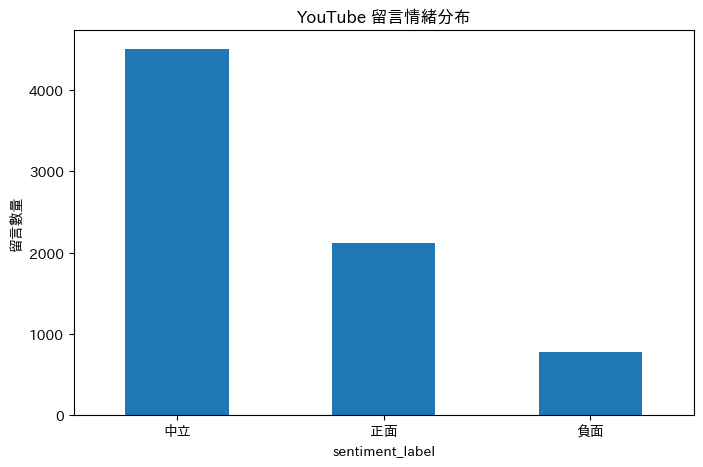

In [5]:
import matplotlib.pyplot as plt

# 統計各情緒類別留言數量
sentiment_counts = df["sentiment_label"].value_counts()

print("=== 留言情緒分布統計 ===")
print(sentiment_counts)

# 設定中文字型
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei"
]
plt.rcParams["axes.unicode_minus"] = False

# 繪製情緒分布長條圖
sentiment_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="YouTube 留言情緒分布"
)

plt.ylabel("留言數量")
plt.xticks(rotation=0)
plt.show()

#### 情緒分析結果  
從情緒分析結果來看，中立情緒留言共計 4,504 筆，占整體留言數約 60.8%，為所有情緒類別中比例最高者；正面留言為 2,112 筆，而負面留言則為 783 筆。此結果顯示，多數留言未呈現明顯的正向或負向情緒傾向，而是集中於情緒較為平穩的文本內容。  
另一方面，負面情緒留言比例相對較低，顯示整體社群討論氛圍偏向正向或中性。然而，由於情緒分析工具主要依據詞彙極性進行判斷，因此部分涉及悲傷、離別、衝突或劇情討論之留言，也可能被歸類為負面情緒。後續將透過主題分析進一步檢視負面情緒留言之內容來源，以避免僅依賴情緒分數進行過度解讀。

### 5. 留言意圖分類分析

在完成情緒分析後，本專案發現大量留言被判定為中立情緒。此結果顯示，許多使用者的留言並非單純表達正面或負面情感，而可能涉及資訊詢問、作品評論、時間軸分享或其他社群互動行為。因此，本專案進一步導入意圖分類（Intent Classification）方法，嘗試從留言內容中辨識使用者的主要互動目的。

本專案採用結合規則式方法（Rule-based）與零樣本分類模型（Zero-shot Classification）的混合式分類流程，以兼顧規則辨識效率與語意理解能力。  
- 首先利用正則表達式（Regular Expression）進行高效率的初步篩選。  
    - 時間軸分享  
        若留言中包含影片時間標記（如 0:35、1:42 等格式），則直接歸類為「時間軸分享」。此類留言通常用於標示特定歌詞、旋律變化或精彩片段的位置。 
    - 資訊詢問
        若留言包含常見日文疑問詞或詢問語句，例如「教えて」、「どうして」、「なぜ」、「誰」、「いつから」、「どこで」等詞彙，則優先歸類為「資訊詢問」。
- 零樣本語意分類
對於無法透過規則式方法明確判定之留言，本專案進一步採用 Hugging Face 提供之多語言零樣本分類模型 MoritzLaurer/mDeBERTa-v3-base-mnli-xnli 進行語意判斷。

零樣本分類（Zero-shot Classification）不需要額外標註訓練資料，而是透過預訓練語言模型直接評估文本與候選標籤之語意相似程度。本專案設定三個日文候選標籤：「質問」(問題、詢問)、「応援」(支持、應援) 、「感想」(心得、評論)。模型會計算留言與各候選標籤之相似程度，並選擇機率最高之標籤作為分類結果。其中「質問」對應為「資訊詢問」，而「応援」與「感想」統一歸類為「一般陳述／應援」。

In [6]:
import pandas as pd
import re
from transformers import pipeline
from tqdm import tqdm

tqdm.pandas(desc="意圖分類進度")

# 載入多語言 Zero-shot 分類模型
print("正在載入分類模型...")

classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
)

# 定義候選標籤
candidate_labels = [
    "質問",
    "応援",
    "感想"
]


# 判斷留言主要互動意圖
def classify_intent(text):

    text = str(text)

    # 空白留言
    if not text.strip():
        return "無意義"

    # 規則一：時間軸分享
    if re.search(r"\d+:\d+", text):
        return "時間軸分享"

    # 規則二：資訊詢問
    if re.search(
        r"教えて|どうして|なぜ|誰|いつから|どこで|詳細",
        text
    ):
        return "資訊詢問"

    # 其餘留言交由 Zero-shot 模型判斷
    try:

        result = classifier(
            text,
            candidate_labels
        )

        top_label = result["labels"][0]

        if top_label == "質問":
            return "資訊詢問"

        return "一般陳述/應援"

    except Exception:
        return "分類失敗"


# 執行意圖分類
print("開始進行意圖分類...")

df["intent"] = (
    df["text"]
    .progress_apply(classify_intent)
)

# 檢視分類結果
display(
    df[
        ["text", "intent"]
    ].head(15)
)

正在載入分類模型...
開始進行意圖分類...


意圖分類進度: 100%|████████████████████████████████████████████████████████████████| 7399/7399 [40:26<00:00,  3.05it/s]


,text,intent
0,いろいろ総なめしてて凄すぎます😭\n 🏆最優秀J-POP楽曲賞🏆\n 🏆Best...,一般陳述/應援
1,音楽の悪魔、YouTubeに2分33秒上陸,資訊詢問
2,正直この曲を納品されたときの映画スタッフ、完成度高すぎてニヤニヤが止まらなかっただろ,一般陳述/應援
3,8年前俺「ピースサイン超える曲は無理だろ」\n2年前俺「kickback超える曲は無理だろ」...,一般陳述/應援
4,パフォーマンスまじでかっこよかった！！,一般陳述/應援
5,2分半しかないこの曲を俺は「もっと長く聴きたい」と思ったけどこの気持ちはデンジの「もっとレゼ...,一般陳述/應援
6,ザラメが溶ける最高温度はだいたい180℃で、ダイナマイトとかの主成分のニトロも180℃くらい...,一般陳述/應援
7,レゼ「ケンシくんみたいな面白い人、はじめて」,資訊詢問
8,数々の受賞おめでとうございます🎉🤭🎉✨️🎉🤭🎉✨️🎉,一般陳述/應援
9,イントロでデンジは表拍で歩いてるのにレゼは裏拍で歩いてるの好きすぎる,一般陳述/應援


### 留言意圖分布統計

完成意圖分類後，統計各類留言之數量分布，並利用長條圖呈現結果，以觀察使用者在留言區中的主要互動模式。

=== 留言意圖分布統計 ===
intent
一般陳述/應援    5456
資訊詢問       1807
時間軸分享       136
Name: count, dtype: int64


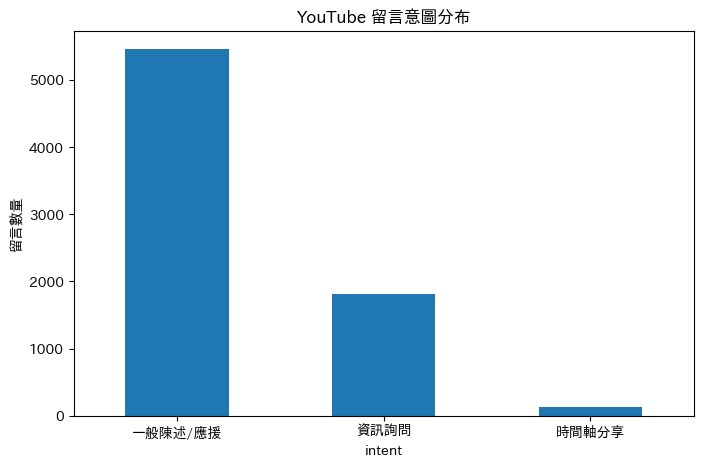

In [7]:
# 統計各類意圖留言數量
intent_counts = df["intent"].value_counts()

print("=== 留言意圖分布統計 ===")
print(intent_counts)

plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei"
]
plt.rcParams["axes.unicode_minus"] = False

intent_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="YouTube 留言意圖分布"
)

plt.ylabel("留言數量")
plt.xticks(rotation=0)
plt.show()

#### 留言意圖分類分析結果

「一般陳述／應援」類型留言共計 5,456 筆，占整體留言數比例最高；其次為「資訊詢問」類型，共計 1,807 筆；而「時間軸分享」則為 136 筆。此結果顯示，使用者在留言區中的主要行為並非單純表達情緒，而是透過評論、心得分享、作品討論及資訊交流等方式參與社群互動。  
值得注意的是，中立情緒留言與一般陳述類留言皆占據較高比例。這意味著大量留言雖然未呈現強烈情感色彩，但仍包含豐富的討論內容與資訊價值。因此，僅依賴情緒分析難以完整理解受眾關注焦點，仍需結合後續的關鍵詞共現網路分析與主題模型分析，進一步探討留言中的核心討論議題。

綜合而言，情緒分析與意圖分類結果顯示，《IRIS OUT》留言區呈現出以討論、交流與作品分享為主的互動特徵。此結果也說明，對於具有跨媒體背景之音樂作品而言，受眾的參與形式不僅限於情緒表達，更可能包含資訊交換、作品解讀及社群互動等多元行為模式。

### 6. 關鍵詞共現網路分析

為了進一步了解聽眾在留言中的討論焦點與語意關聯，本專案利用關鍵詞共現分析（Word Co-occurrence Analysis）建構語意網路，觀察不同主題之間的連結關係及討論脈絡。

#### 6.1 關鍵詞萃取與文本正規化  
本專案首先利用 Janome 日文形態素分析器（Tokenizer）對留言文本進行斷詞處理，並依據詞性資訊保留具有較高語意價值之詞彙，包括名詞、動詞及形容詞。另一方面，為降低常見功能詞對分析結果的干擾，建立停用詞（Stopwords）列表，移除助詞、代名詞及高頻但低語意價值之詞彙。  
此外，由於社群留言中經常出現不同寫法的專有名詞，本專案進一步進行文本正規化處理。例如將「IRIS OUT」、「IRISOUT」以及片假名形式之「アイリスアウト」統一為同一詞彙；將「米津玄師」統一轉換為「米津」；將「JANE DOE」統一轉換為「JANEDOE」，以避免同一概念被切分為多個獨立節點而影響分析結果。

In [8]:
#讀取原始資料
df = pd.read_csv('youtube_comments.csv')

def clean_japanese_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    
    #移除時間軸
    text = re.sub(r'\d+:\d+', '', text)
    #移除網址
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    #移除 Emoji
    text = emoji.replace_emoji(text, replace='')
    #移除換行符號與多餘空白
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("正在進行資料清理...")
df['clean_text'] = df['text'].apply(clean_japanese_text)
df

正在進行資料清理...


,text,votes,time,author,clean_text
0,いろいろ総なめしてて凄すぎます😭\n 🏆最優秀J-POP楽曲賞🏆\n 🏆Best...,77,17 小時前 (已編輯),@uzuuzuyuzuki,いろいろ総なめしてて凄すぎます 最優秀J-POP楽曲賞 Best Japanese Song...
1,音楽の悪魔、YouTubeに2分33秒上陸,12萬,8 個月前,@まな板-A,音楽の悪魔、YouTubeに2分33秒上陸
2,正直この曲を納品されたときの映画スタッフ、完成度高すぎてニヤニヤが止まらなかっただろ,2460,5 個月前,@13きなこ,正直この曲を納品されたときの映画スタッフ、完成度高すぎてニヤニヤが止まらなかっただろ
3,8年前俺「ピースサイン超える曲は無理だろ」\n2年前俺「kickback超える曲は無理だろ」...,2001,8 個月前,@なな-b4w3g,8年前俺「ピースサイン超える曲は無理だろ」 2年前俺「kickback超える曲は無理だろ」 ...
4,パフォーマンスまじでかっこよかった！！,38,13 小時前,@Meiyfn-77,パフォーマンスまじでかっこよかった！！
...,...,...,...,...,...
7394,😈🤬😠😡,0,9 天前 (已編輯),@天安門-r9n,
7395,都過了快100年，卻一直要現在的日本人去承擔軍國主義時期的錯誤，而故意忽視日本在改革開放時期...,0,9 天前,@天安門-r9n,都過了快100年，卻一直要現在的日本人去承擔軍國主義時期的錯誤，而故意忽視日本在改革開放時期...
7396,🪃,7,9 小時前,@nagaoka1056,
7397,アイコン気持ち悪い,3,10 天前,@ベンキノスケ,アイコン気持ち悪い


In [10]:
t = Tokenizer()

# 定義停用詞
stopwords = [
    'する', 'いる', 'ある', 'なる', 'の', 'こと', 'もの', 'これ', 'それ', 'ん', 'よう', 'てる', 
    '曲', '歌', 'さん', 'れる', 'ない', 'くる', '思う', '言う', 'the', 'it', 'was', 'in', 'and', 'to',
    'いう', 'そう', '何', '目', '人', '者', '数', '二', 'ヶ月', '位', '今日', '一','this', 'of', 'movie', 'MAJ'
]

def extract_keywords(text):
    """
    關鍵詞萃取函數

    流程：
    1. 專有名詞正規化
    2. Janome 斷詞
    3. 保留名詞、動詞、形容詞
    4. 移除停用詞
    """

    if pd.isna(text) or text == "":
        return []

    # 統一 IRIS OUT 相關寫法
    text = re.sub(
        r'IRIS\s+OUT',
        'IRISOUT',
        text,
        flags=re.IGNORECASE
    )

    text = text.replace(
        'アイリスアウト',
        'IRISOUT'
    )

    text = text.replace(
        'アイリス アウト',
        'IRISOUT'
    )

    # 統一米津玄師名稱
    text = re.sub(
        r'米津\s*玄師',
        '米津',
        text
    )

    text = text.replace(
        '玄師',
        '米津'
    )

    # 統一 JANE DOE
    text = re.sub(
        r'JANE\s*DOE',
        'JANEDOE',
        text
    )

    keywords = []

    for token in t.tokenize(text):

        pos = token.part_of_speech.split(',')[0]
        base_form = token.base_form

        # 僅保留名詞、動詞與形容詞
        if pos in ['名詞', '動詞', '形容詞']:

            if (
                base_form not in stopwords
                and
                (
                    len(base_form) > 1
                    or re.match(r'[\u4e00-\u9faf]', base_form)
                )
            ):
                keywords.append(base_form)

    return keywords

print("正在提取關鍵字...")
df['keywords'] = df['clean_text'].apply(extract_keywords)
display(df[['clean_text', 'keywords']].head())

正在提取關鍵字...


,clean_text,keywords
0,いろいろ総なめしてて凄すぎます 最優秀J-POP楽曲賞 Best Japanese Song...,"[総なめ, 凄い, すぎる, 最優秀, POP, 楽曲, 賞, Best, Japanese..."
1,音楽の悪魔、YouTubeに2分33秒上陸,"[音楽, 悪魔, YouTube, 分, 33, 秒, 上陸]"
2,正直この曲を納品されたときの映画スタッフ、完成度高すぎてニヤニヤが止まらなかっただろ,"[正直, 納品, とき, 映画, スタッフ, 完成, 度, 高, すぎる, 止まる]"
3,8年前俺「ピースサイン超える曲は無理だろ」 2年前俺「kickback超える曲は無理だろ」 ...,"[年, 前, 俺, ピース, サイン, 超える, 無理, 年, 前, 俺, kickback..."
4,パフォーマンスまじでかっこよかった！！,"[パフォーマンス, まじ, かっこよい]"


#### 6.2 關鍵詞共現關係建構  
完成關鍵詞萃取後，本專案以單則留言作為分析單位，統計同一留言中同時出現之詞彙組合，並建立詞彙共現矩陣（Word Co-occurrence Matrix）。  
在每筆留言中，先移除重複關鍵詞，再利用兩兩組合方式產生詞彙配對，最後累計所有留言中的共現次數作為邊權重（Edge Weight）。共現次數越高，表示兩個詞彙越常在相同留言中被共同討論，其語意關聯程度也相對較高。

In [11]:
# 將每筆留言的關鍵字兩兩配對
edges = []
for keyword_list in df['keywords']:
    # 移除重複詞彙，避免自己跟自己連線
    unique_keywords = list(set(keyword_list)) 
    # 產生兩兩組合 (A, B)
    if len(unique_keywords) >= 2:
        for pair in itertools.combinations(unique_keywords, 2):
            # 排序確保 (A, B) 和 (B, A) 視為同一組
            edges.append(tuple(sorted(pair)))

# 計算每對組合出現的次數
edge_counts = Counter(edges)

# 轉換成 DataFrame 方便檢視
edge_df = pd.DataFrame([
    {'node1': pair[0], 'node2': pair[1], 'weight': weight} 
    for pair, weight in edge_counts.items()
])

# 依照權重排序，檢視最常一起出現的詞彙對
edge_df = edge_df.sort_values(by='weight', ascending=False).reset_index(drop=True)
display(edge_df.head(10))

,node1,node2,weight
0,億,再生,153
1,行く,見る,140
2,億,回,125
3,映画,行く,95
4,再生,回,91
5,映画,見る,85
6,行く,観,67
7,チェリー,部落,53
8,回,行く,52
9,映画,観,47


#### 6.3 關鍵詞共現網路視覺化
本專案利用 NetworkX 建立關鍵詞共現網路，其中節點（Node）代表關鍵詞，邊（Edge）代表詞彙之間的共現關係，而邊的權重則表示共現頻率。  
為降低低頻隨機共現對網路結構的干擾，本專案設定共現門檻值（Threshold）為 20，僅保留共現次數達 20 次以上之詞彙連結。此做法有助於凸顯較具代表性的討論結構，並提高網路圖之可讀性。  
在視覺化階段，本專案利用 Connected Components 將彼此不相連的語意群集分別辨識出來，並對各群集獨立進行版面配置，再透過座標平移方式將不同群集分散顯示。此方法可有效降低大型網路圖中節點重疊與標籤遮蔽問題，使不同討論主題之間的群聚結構更加清晰。  
透過關鍵詞共現網路分析，不僅能觀察高頻關鍵詞之間的關聯性，也能進一步辨識留言區中不同討論群體所形成的語意聚落（Semantic Communities），為後續主題模型分析提供更具結構性的觀察視角。

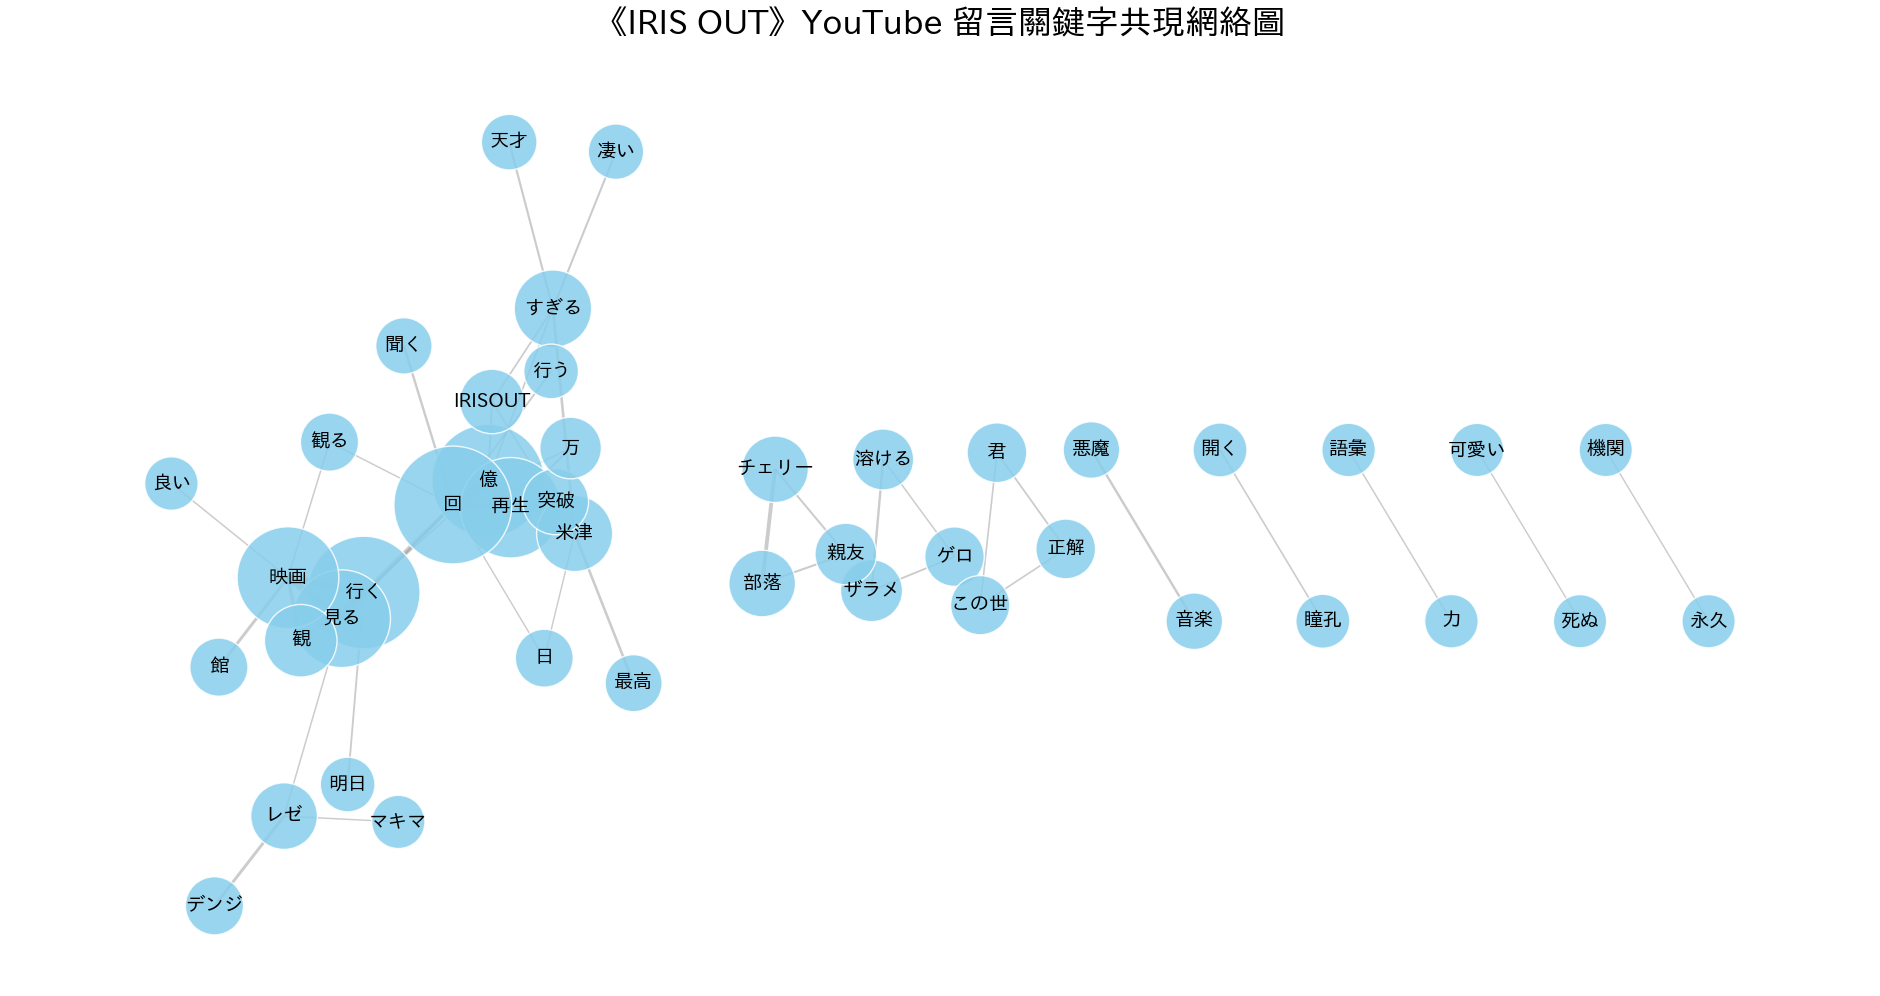

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np

THRESHOLD = 20
filtered_edges = edge_df[edge_df['weight'] >= THRESHOLD]

G_static = nx.Graph()
for index, row in filtered_edges.iterrows():
    G_static.add_edge(row['node1'], row['node2'], weight=row['weight'])

components = sorted(nx.connected_components(G_static), key=len, reverse=True)

pos = {}
x_offset = 0 


for comp in components:
    subgraph = G_static.subgraph(comp)
    
    island_scale = max(2.0, len(comp) * 0.4) 

    sub_pos = nx.spring_layout(subgraph, k=1.5, scale=island_scale, seed=42)
    
    if sub_pos:
        xs = [coords[0] for coords in sub_pos.values()]
        min_x, max_x = min(xs), max(xs)

        for node in sub_pos:
            sub_pos[node][0] = sub_pos[node][0] - min_x + x_offset
            
        pos.update(sub_pos)

        x_offset += (max_x - min_x) + (island_scale * 0.5)

plt.figure(figsize=(24, 12)) 

# 動態計算節點大小與線條粗細
node_weights = dict(G_static.degree(weight='weight'))
max_node_weight = max(node_weights.values()) if node_weights else 1
node_sizes = [ (node_weights[node] / max_node_weight) * 6000 + 1200 for node in G_static.nodes() ]

weights = [G_static[u][v]['weight'] for u, v in G_static.edges()]
max_weight = max(weights) if weights else 1
normalized_weights = [w / max_weight * 8 for w in weights] 

nx.draw_networkx_nodes(G_static, pos, node_color='skyblue', node_size=node_sizes, alpha=0.85, edgecolors='white')
nx.draw_networkx_edges(G_static, pos, width=normalized_weights, edge_color='gray', alpha=0.4)
nx.draw_networkx_labels(G_static, pos, font_family='IPAexGothic', font_size=14, font_weight='bold')

plt.axis('off')
plt.title(f'《IRIS OUT》YouTube 留言關鍵字共現網絡圖', fontsize=24, pad=20)
plt.show()

#### 關鍵詞共現網路分析  
節點大小代表詞彙的重要程度與連結強度，連線則表示詞彙在同一則留言中共同出現的頻率。透過觀察不同詞彙群聚結構，可以進一步了解聽眾的主要討論焦點與語意關聯。

首先，位於圖左側的主要語意群集為整體網路中規模最大的討論區域。該群集以「億」、「再生」、「回」等詞彙作為核心節點，顯示大量留言與歌曲播放量、觀看次數及再生紀錄相關。此現象反映部分使用者會透過留言參與播放里程碑的慶祝與分享，形成具有社群互動特性的討論模式。

在同一群集中，亦可觀察到「映画」、「見る」、「レゼ」、「マキマ」等詞彙形成緊密連結。由於《IRIS OUT》同時作為《鏈鋸人：蕾潔篇》主題曲，因此相關角色名稱與電影詞彙頻繁共同出現，顯示部分聽眾會將歌曲內容與電影劇情、角色設定或觀影體驗一併討論，反映跨媒體作品所帶來的討論延伸效果。

此外，「米津」、「天才」、「最高」等詞彙形成另一組關聯結構，顯示許多留言聚焦於對創作者及作品本身的評價。此類詞彙多帶有肯定與讚賞意涵，與前述情緒分析中正向留言占有一定比例的結果相互呼應。

圖中央則可觀察到由「チェリー（櫻桃）」、「ザラメ（粗砂糖）」、「溶ける（融化）」及相關詞彙所形成的小型語意群集。這些詞彙多與歌詞內容或象徵意象相關，顯示部分聽眾並非僅停留於歌曲欣賞層面，而是進一步針對歌詞內容、象徵符號及作品意涵進行討論與解讀。

另一方面，圖右側仍存在若干規模較小的詞彙群集，例如「音楽－悪魔」、「永久－機関」等連結。雖然這些群集規模較小，但其詞彙內容與《鏈鋸人》作品世界觀具有一定關聯性，顯示部分留言聚焦於動漫設定、角色背景及作品概念的延伸討論。

整體而言，關鍵詞共現網路顯示《IRIS OUT》留言區的討論內容主要可歸納為三個方向：其一為歌曲播放量與再生紀錄相關之社群互動；其二為電影角色與跨媒體內容之延伸討論；其三為歌詞意象與作品意涵之解讀。此結果說明，聽眾的參與行為不僅侷限於音樂本身，更延伸至作品敘事、角色設定及社群文化等多個層面。

### 7. BERTopic 主題探勘與 LDA 主題模型分析  
由於 YouTube 留言屬於典型的社群短文本資料，具有篇幅短、語意資訊有限及詞彙稀疏（Sparsity）等特性，若直接使用傳統主題模型進行分析，容易受到雜訊留言與低品質文本影響。因此，本專案採用結合 BERTopic 與 LDA 的雙階段主題分析流程，以提升主題辨識能力與分析品質。

綜合而言，此雙階段分析流程不僅能降低社群留言中的雜訊干擾，也能結合深度語意表示與傳統主題模型的優勢，從大量留言中萃取出具有解釋價值的核心討論議題。

#### 7.1 BERTopic 主題探勘與雜訊篩選  
本專案首先利用 BERTopic 對全部留言進行初步主題探勘。BERTopic 結合多語言 Sentence Transformer、UMAP 降維以及密度式分群方法，能夠將語意相近的留言自動聚集為不同主題群組。  
在完成第一次主題分析後，本專案檢視各主題之代表關鍵詞與留言內容，發現部分主題主要由廣告訊息、疑似機器人留言以及與專案主題無關之討論所構成。為避免此類雜訊影響後續主題建模結果，本專案將 Topic -1、Topic 1 及 Topic 7 視為雜訊主題並予以排除。  
經篩選後，共保留 4,571 筆與歌曲討論相關之有效留言，作為後續分析之主要語料。

In [13]:
# 取得完成前處理後的留言文本
# 排除空白留言後轉換為文件列表
docs = df[df['clean_text'].str.strip() != '']['clean_text'].tolist()

print("開始建立 BERTopic 主題模型...")

# 建立 UMAP 降維模型
# 固定 random_state 以提高結果重現性
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)

# 建立 BERTopic 模型
# 使用多語言語意嵌入與自動主題數量調整
topic_model = BERTopic(
    language="multilingual", 
    nr_topics="auto",
    umap_model=umap_model  # 加入這行來固定隨機行為
)

# 進行訓練
topics, probabilities = topic_model.fit_transform(docs)

# 查看主題摘要資訊
# Count 為主題留言數量
# Name 為代表性關鍵詞組合
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

開始建立 BERTopic 主題模型...


D:\Anaconda\envs\nlp_env\lib\site-packages\bertopic\backend\_sentencetransformers.py:4: DeprecationWarning: Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.
  from sentence_transformers.models import StaticEmbedding


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2147,-1_it_the_daarin_ah,"[it, the, daarin, ah, was, movie, and, ha, to,...",[I watched the movie in the theater yesterday!...
1,0,1297,0_正解_行きます_それな_行きました,"[正解, 行きます, それな, 行きました, わかる, 同じく, 米津最高, はい, わん,...","[行きます！, 行きます。, 正解！！正解！！]"
2,1,489,1_robinskull_ふーちゃん_z8p_arashi,"[robinskull, ふーちゃん, z8p, arashi, user, 人妻大好き浦川...","[​ @ふーちゃん-z8p ふーちゃん、大丈夫だよね, 6/1 Spotifyデイリーランキ..."
3,2,181,2_2億_200_そろそろ俺も2億回再生だなぁ_二億いってるやん,"[2億, 200, そろそろ俺も2億回再生だなぁ, 二億いってるやん, なお, 2億いったー...","[2億...?2億...2億.....!?, 2億！！！！？？？！！, ダメダメ なのに身体..."
4,3,180,3_song_this_intense_to,"[song, this, intense, to, its, この曲はマキマに聴かれている,...","[I like this song, My guppies now 2 tank have ..."
5,4,165,4_映画を観に行く_映画を見に行く_映画最高_映画を,"[映画を観に行く, 映画を見に行く, 映画最高, 映画を, 映画, cinema, in, ...","[映画を観に行く, 映画を観に行く, 映画を観に行く……]"
6,5,144,5_ありがとうございます_おめでとう_ありがとう_感謝,"[ありがとうございます, おめでとう, ありがとう, 感謝, 楽しみ, 楽しもう, ありがた...","[ありがとうございます, ありがとうございます, ありがとうございます]"
7,6,133,6_天才_天才か_天才かよ_天才だ,"[天才, 天才か, 天才かよ, 天才だ, 天才や, 天才すぎる, 天才だろ, 天才やん, 天...","[天才？, 天才！天才！, 天才！天才！天才！]"
8,7,115,7_チャンネルまで行って右上のユーザーを報告から_貴族だから礼儀よくしてね_commenti...,"[チャンネルまで行って右上のユーザーを報告から, 貴族だから礼儀よくしてね, comment...",[​ @yd1150 まずは「コメントさせていただきます」 その次に「コメント失礼します」 ...
9,8,109,8_勝てる気がしない_推すなよ_見るなよ_うん,"[勝てる気がしない, 推すなよ, 見るなよ, うん, 俺もやで, 俺らで1位を継続させるんや...",[デンジくんはね 蕩尽なんて読めないし 頸動脈なんて知らないし やること全部が100点じゃな...


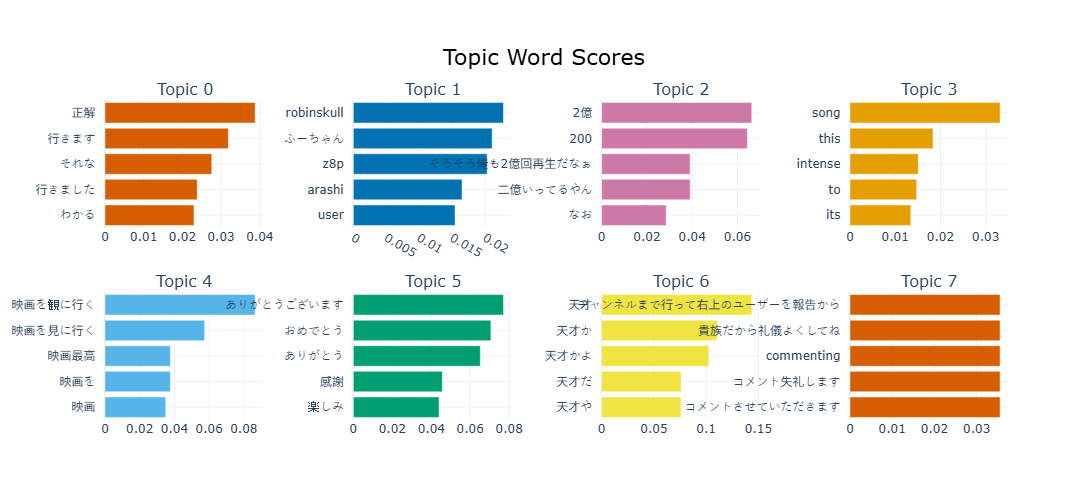

In [14]:
fig = topic_model.visualize_barchart(top_n_topics=8)
fig.show()

#### BERTopic 主題探勘與雜訊篩選結果  
透過檢視各主題之代表詞彙，可以發現部分主題主要由與歌曲內容無關的留言所構成。

其中，Topic 1 主要包含 robinskull、ふーちゃん、z8p 等帳號名稱及缺乏明確語意之文字內容，顯示其可能為廣告留言、機器人帳號或低資訊價值文本。另一方面，Topic 7 則出現「チャンネルまで行って右上のユーザーを報告から」、「コメント失礼します」等詞句，主要反映留言區內部之檢舉、提醒及使用者互動行為，而非針對歌曲本身進行討論。

基於上述觀察，本專案將 Topic -1、Topic 1 及 Topic 7 視為與研究主題關聯較低之雜訊主題，並於後續分析中予以排除，以提升主題模型之品質與可解釋性。

#### 7.2 BERTopic 主題精煉  
完成雜訊移除後，本專案再次利用 BERTopic 對純化後之留言資料進行主題分析，使模型能夠在較少干擾的語料環境下學習核心討論內容。  
透過第二次 BERTopic 分析，本專案獲得較具代表性的主題關鍵詞與語意群組，作為後續 LDA 主題模型之語料基礎。

剩餘留言：4571 筆

正在針對純淨資料訓練固定主題模型...


,Topic,Count,Name,Representation,Representative_Docs
0,-1,257,-1_jane_有能_and_the,"[jane, 有能, and, the, doe, to, そろそろ俺も2億回再生だなぁ, ...",[@shadowkitty777 Idk wanna go to the cinema i ...
1,0,3458,0_それな_正解_行きます_わかる,"[それな, 正解, 行きます, わかる, out, 行きました, iris, ありがとうござ...","[それな, それな, それな]"
2,1,598,1_the_of_it_and,"[the, of, it, and, this, to, movie, was, in, my]",[@Philghg it is VERY dependant on the anime fo...
3,2,181,2_2億_200_million_なお,"[2億, 200, million, なお, 死亡者数, 2億おめ, 200000000, ...","[2億！, 2億！！！！！, 2億...?2億...2億.....!?]"
4,3,64,3_japan_japanese_best_awards,"[japan, japanese, best, awards, song, in, musi...",[MUSIC AWARDS JAPAN 2026 最優秀デジタルカルチャー アーティスト賞 ...
5,4,13,4_世の中全てがヤラセだらけで_ユーチューバー_気付いてる人も多いと思うけど_放送作家が事前...,"[世の中全てがヤラセだらけで, ユーチューバー, 気付いてる人も多いと思うけど, 放送作家が...",[気付いてる人も多いと思うけど、 【ユーチューバー ブーム】も 今となると ブーム自体が全部...


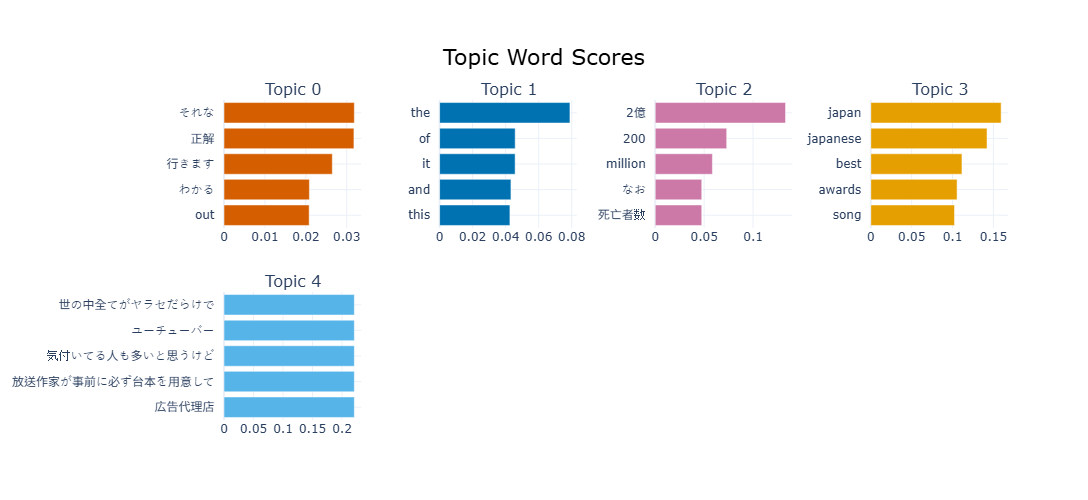

In [16]:
# 取得所有留言與它們對應的 Topic 標籤表
doc_info = topic_model.get_document_info(docs)

# 設定需排除之雜訊主題
bad_topics = [-1, 1, 7]

# 移除雜訊主題後保留有效留言
clean_docs = doc_info[~doc_info['Topic'].isin(bad_topics)]['Document'].tolist()
print(f"剩餘留言：{len(clean_docs)} 筆")


# 第二階段 BERTopic 分析
# 使用過濾後資料重新建立主題模型
print("\n正在針對純淨資料訓練固定主題模型...")

# 指定最終主題數量
final_topic_count = 6 

topic_model_final = BERTopic(language="multilingual", nr_topics=final_topic_count, umap_model=umap_model)
topics_final, _ = topic_model_final.fit_transform(clean_docs)

# 視覺化各主題代表關鍵詞
final_topic_info = topic_model_final.get_topic_info()
display(final_topic_info.head(final_topic_count + 1))

fig_final = topic_model_final.visualize_barchart(top_n_topics=final_topic_count)
fig_final.show()

#### BERTopic 主題精煉結果  
相較於第一次分析，保留下來的主題更能反映受眾實際關注的討論內容。

其中，Topic 3 主要由「japan」、「japanese」、「best」、「awards」及「song」等英文詞彙構成，顯示部分海外使用者聚焦於歌曲評價及獲獎相關討論。Topic 2 則包含「2億」、「200」、「million」等播放量相關詞彙，反映留言區存在大量關於觀看次數及作品人氣的討論內容。

此外，Topic 0 出現「正解」、「行きます」、「わかる」等詞彙，呈現聽眾對作品內容的回應與共鳴；而 Topic 1 主要由英文常用詞所組成，顯示資料集中仍存在部分英文留言與高頻英文詞彙。

整體而言，第二次 BERTopic 分析顯示，《IRIS OUT》留言區的核心討論內容主要圍繞於作品評價、觀看成就、跨國受眾參與以及歌曲相關討論等面向，與前述情緒分析、意圖分類及關鍵詞共現網路分析結果相互呼應。

#### 7.3 LDA 主題模型建構  
在取得純化後之關鍵詞資料後，本專案利用 Gensim 套件建立 LDA（Latent Dirichlet Allocation）主題模型。  
首先透過 Dictionary 建立詞彙字典，並利用 filter_extremes(no_below=5, no_above=0.5) 過濾過低頻與過高頻詞彙，以降低極端詞彙對模型造成之影響。接著建立詞袋模型（Bag-of-Words Corpus），作為 LDA 模型之輸入資料。  
模型訓練參數設定如下：主題數量（num_topics）= 4、random_state = 42、passes = 15、 alpha = auto。  
完成模型訓練後，利用 pyLDAvis 進行主題視覺化分析，以觀察不同主題之分布情形及其關鍵詞特徵。

In [17]:
# 取得 BERTopic 分析所使用的有效留言資料
df_filtered = df[df['clean_text'].str.strip() != ''].copy()

# 將 BERTopic 主題標籤加入資料集
df_filtered['Topic'] = doc_info['Topic'].values

# 設定需排除之雜訊主題
bad_topics = [-1, 1, 7]

# 保留與研究主題相關之留言資料
pure_df = df_filtered[~df_filtered['Topic'].isin(bad_topics)]
clean_keywords = pure_df['keywords']

id2word = corpora.Dictionary(clean_keywords)

# 移除過低頻與過高頻詞彙
id2word.filter_extremes(no_below=5, no_above=0.5)

corpus = [id2word.doc2bow(text) for text in clean_keywords]

print("完成語料建構")
print(f"字典詞彙數量：{len(id2word)}")
print(f"語料文件數量：{len(corpus)}")

完成語料建構
字典詞彙數量：826
語料文件數量：4571


In [18]:
# 設定主題數量
num_topics = 4

print(f"開始訓練 {num_topics} 個主題的 LDA 模型")

lda_model = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=num_topics,
    random_state=42,
    passes=15,          # 模型訓練次數
    alpha='auto',       # 自動估計主題分布參數
    per_word_topics=True
)

for idx, topic in lda_model.print_topics(-1, num_words=10):
    print(f"\n【主題 {idx + 1}】:\n {topic}")

開始訓練 4 個主題的 LDA 模型

【主題 1】:
 0.147*"億" + 0.091*"回" + 0.069*"再生" + 0.021*"悪魔" + 0.020*"すぎる" + 0.019*"日" + 0.017*"万" + 0.017*"突破" + 0.016*"聴く" + 0.016*"IRISOUT"

【主題 2】:
 0.040*"部落" + 0.037*"チェリー" + 0.030*"正解" + 0.026*"親友" + 0.020*"受賞" + 0.018*"聞く" + 0.016*"!!" + 0.014*"嬉しい" + 0.014*"来る" + 0.013*"YouTube"

【主題 3】:
 0.058*"米津" + 0.020*"IRISOUT" + 0.017*"全部" + 0.016*"ヤラセ" + 0.015*"わかる" + 0.015*"最高" + 0.014*"今" + 0.014*"笑" + 0.014*"2026" + 0.011*"賞"

【主題 4】:
 0.101*"行く" + 0.073*"見る" + 0.036*"映画" + 0.034*"すぎる" + 0.031*"天才" + 0.026*"レゼ" + 0.019*"デンジ" + 0.016*"最高" + 0.015*"俺" + 0.014*"観"


#### 主題視覺化

本專案利用 pyLDAvis 將 LDA 主題模型結果投影至二維空間，以觀察各主題之間的距離關係與代表性關鍵詞分布。

主題圓圈面積代表主題占比，而主題之間的距離則反映語意相似程度。

In [19]:
pyLDAvis.enable_notebook()

print("正在生成互動圖表...")

vis_data = gensimvis.prepare(lda_model, corpus, id2word, mds='mmds')

vis_data

正在生成互動圖表...


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.267209 -0.194584       1        1  29.578316
3     -0.185096  0.262693       2        1  26.010672
0      0.175746 -0.271347       3        1  22.813649
1      0.276559  0.203238       4        1  21.597362, topic_info=        Term        Freq       Total Category  logprob  loglift
81         億  500.000000  500.000000  Default  30.0000  30.0000
78        行く  393.000000  393.000000  Default  29.0000  29.0000
52         回  311.000000  311.000000  Default  28.0000  28.0000
79        見る  283.000000  283.000000  Default  27.0000  27.0000
131       再生  237.000000  237.000000  Default  26.0000  26.0000
..       ...         ...         ...      ...      ...      ...
187      for   23.545556   30.951106   Topic4  -4.9189   1.2591
314       読む   23.438735   31.343998   Topic4  -4.9234   1.2420
55         中   23.971591   51.534625   Topic4  -4.9009   0.7672
255      ちゃう   20.943368   26.746109   Topic4  -5.0360   1.2880
70   IRISOUT   28.725492  170.262045   Topic4  -4.7200  -0.2470

[201 rows x 6 columns], token_table=      Topic      Freq Term
term                      
134       4  0.980185   !!
110       2  0.772305  ...
110       4  0.210629  ...
259       2  0.323664   10
259       3  0.647328   10
...     ...       ...  ...
105       2  0.965857   開く
332       1  0.975911   関係
14        1  0.642509   音楽
14        3  0.345966   音楽
459       3  0.957368  頑張る

[215 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 4, 1, 2])

#### LDA 主題模型建構結果
從 Intertopic Distance Map 可以觀察到，四個主題在二維語意空間中具有一定程度的區隔性，顯示留言內容可被歸納為數個相對獨立的討論方向。整體而言，主題主要涵蓋作品評價、動漫劇情、播放里程碑以及歌詞與創作者相關討論等面向。

其中，主題一（29.6%） 為占比最高之主題，代表詞彙包括「米津」、「IRISOUT」、「最高」、「賞」、「ブーム」以及「ユーチューバー」等。此主題主要反映聽眾對歌曲本身及創作者的評價，同時包含部分與媒體、網路話題相關之延伸討論。

主題二（26.0%） 包含「映画」、「レゼ」、「デンジ」、「マキマ」、「チェンソーマン」等關鍵詞，顯示大量留言聚焦於《鏈鋸人：蕾潔篇》及相關角色討論。由於《IRIS OUT》作為電影主題曲，因此歌曲與動畫劇情之間形成高度連結，反映出跨媒體作品所帶來的討論效應。

主題三（22.8%） 主要由「億」、「回」、「再生」、「万」、「突破」及「IRISOUT」等詞彙構成，顯示留言區存在大量與觀看次數、串流成績及播放里程碑相關的討論內容。此外，「Lemon」等代表性作品名稱亦出現在此主題中，反映部分聽眾會將《IRIS OUT》與米津玄師過往作品進行比較或連結。

主題四（21.6%） 則包含「部落」、「チェリー」、「親友」、「ハチ」、「ザラメ」等詞彙，較偏向歌詞意象、作品象徵及創作者背景相關討論。此類留言顯示部分聽眾不僅關注歌曲本身，也會進一步解讀歌詞內容與創作脈絡。

綜合而言，LDA 主題模型結果與前述關鍵詞共現網路分析高度一致，皆指出《IRIS OUT》留言區的核心討論主要圍繞於作品評價、動漫角色與劇情、觀看里程碑，以及歌詞意象與創作者相關內容。此結果反映《IRIS OUT》的討論已不侷限於音樂作品本身，而是進一步延伸至動畫劇情、角色形象及粉絲社群互動等跨媒體內容。


#### 7.4 模型評估

為評估主題模型品質，本專案進一步計算困惑度（Perplexity）與主題相長性（Coherence Score）等指標。

In [21]:
from gensim.models import CoherenceModel

# 計算困惑度 (Perplexity)
log_perplexity = lda_model.log_perplexity(corpus)
perplexity = np.exp(-log_perplexity)

print("LDA 模型評估結果")
print(f"模型的對數困惑度 (Log Perplexity) : {log_perplexity:.4f}")
print(f"轉換後的傳統困惑度 (Perplexity)     : {perplexity:.4f}")

# 計算主題相長性 (Coherence Score / PMI)

# 同時計算 c_v 與 PMI (c_uci)
coherence_model_cv = CoherenceModel(
    model=lda_model, texts=clean_keywords, dictionary=id2word, coherence="c_v"
)
coherence_cv = coherence_model_cv.get_coherence()

coherence_model_pmi = CoherenceModel(
    model=lda_model, texts=clean_keywords, dictionary=id2word, coherence="c_uci"
)
coherence_pmi = coherence_model_pmi.get_coherence()

print(f"主題相長性得分 (Coherence c_v)      : {coherence_cv:.4f}")
print(f"標準 PMI 相長性得分 (Coherence PMI) : {coherence_pmi:.4f}")

LDA 模型評估結果
模型的對數困惑度 (Log Perplexity) : -6.3143
轉換後的傳統困惑度 (Perplexity)     : 552.3878
主題相長性得分 (Coherence c_v)      : 0.3706
標準 PMI 相長性得分 (Coherence PMI) : -7.7451


#### 模型評估結果  
評估結果如下：  
Log Perplexity: -6.3143、Perplexity: 552.3880、Coherence (c_v): 0.3706、Coherence (PMI / c_uci): -7.7451  
其中，Perplexity 主要用於衡量模型對語料的擬合能力；Coherence Score 則反映主題關鍵詞之語意一致性。由於社群短文本本身具有高度稀疏特性，因此主題模型通常難以取得非常高的 Coherence 分數。然而 Perplexity 反映出本專案透過 BERTopic 預先篩除雜訊留言後，再進行 LDA 主題建模，有助於提升主題分析結果之可讀性與解釋能力，進而獲得較具代表性的討論主題。

## D. 結論
本專案以米津玄師《IRIS OUT》YouTube 留言資料作為分析對象，透過資料清理、情緒分析、意圖分類、關鍵詞共現網路分析以及 BERTopic 與 LDA 主題模型等自然語言處理方法，探討數位音樂作品在跨媒體情境下所形成的社群互動現象與受眾討論特徵。  

研究結果顯示，《IRIS OUT》留言區呈現出明顯的跨媒體討論特徵。除了對歌曲本身的評價之外，許多留言亦涉及《鏈鋸人：蕾潔篇》相關角色、劇情內容及歌詞意象的解讀。這顯示當音樂作品與熱門 IP 結合時，部分受眾的參與形式已不再侷限於音樂欣賞，而會進一步延伸至作品敘事、角色關係與文化符號等層面的交流與討論。  

情緒分析結果顯示，中立留言占整體留言超過六成，而意圖分類結果則指出大量留言屬於一般陳述、心得分享及資訊交流類型。此結果反映留言區不僅是情緒表達的空間，同時也是使用者分享觀點、交換資訊及參與社群互動的重要場域。相較於傳統以正負情緒作為主要分析焦點的研究，本專案發現受眾的討論內容與互動目的同樣具有重要的分析價值。  

關鍵詞共現網路與主題模型分析進一步揭露了留言區的主要討論方向。整體而言，討論內容可大致歸納為四個面向：作品與創作者評價、電影及角色相關討論、播放量與觀看里程碑，以及歌詞意象與創作背景解讀。其中，播放量突破、角色劇情討論及歌詞象徵意涵等主題均展現出高度活躍的社群參與現象，反映聽眾對作品的關注已延伸至音樂以外的文化脈絡。  

在方法層面，本專案建構了一套適用於日文社群短文本的分析流程，結合 BERTopic 與 LDA 進行雙階段主題分析。首先利用 BERTopic 進行初步主題探勘與雜訊辨識，再透過 LDA 建立可解釋性較高的主題模型。實驗結果顯示，此流程能有效協助處理社群留言中常見的語料稀疏、語言混雜及雜訊干擾問題，並提升主題分析結果的可讀性與解釋能力。  

綜合而言，《IRIS OUT》不僅是一首受到廣泛關注的音樂作品，也成為串連動畫劇情、粉絲文化與社群互動的重要媒介。本專案所建構之 NLP 分析流程，除了有助於理解數位音樂社群的討論結構與互動模式外，亦可作為未來跨媒體行銷分析、社群輿情研究及使用者內容探勘之參考方法。  
